In [70]:
import matplotlib.pyplot as plt

In [71]:
dihedrals = [10*ang for ang in range(19)]

ang = []
eng = []

for dihedral in dihedrals:

    with open(f'../sp/dihedral_{dihedral:03d}/sp.out') as file:
        lines = file.readlines()

    for line in lines[::-1]:
        if line.startswith("FINAL SINGLE POINT ENERGY"):
            energy = float(line.split()[-1])
            break

    ang.append(dihedral)
    eng.append(energy)
    print(f'{dihedral:3} {energy:.8f}')

glob_min = min(eng)
eng = [e-glob_min for e in eng] # in Hartree
eng = [e*627.509 for e in eng] # in kcal/mol

  0 -169.81392824
 10 -169.81286964
 20 -169.80977804
 30 -169.80488125
 40 -169.79855564
 50 -169.79133345
 60 -169.78392077
 70 -169.77723971
 80 -169.77243946
 90 -169.77067861
100 -169.77248485
110 -169.77730852
120 -169.78398439
130 -169.79136567
140 -169.79853746
150 -169.80480394
160 -169.80964363
170 -169.81269290
180 -169.81373298


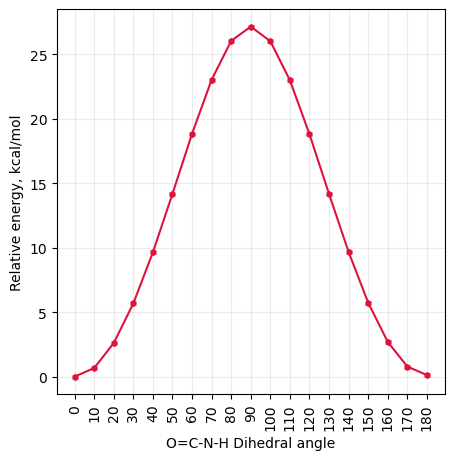

In [72]:
fig,ax = plt.subplots(figsize=(5,5))

ax.plot(ang,eng,marker='h', markersize=4,color='crimson')

ax.set_xticks(ang)
ax.set_xticklabels(ang,rotation=90)

ax.set_xlabel('O=C-N-H Dihedral angle')
ax.set_ylabel('Relative energy, kcal/mol')

ax.grid(alpha=0.25)

plt.savefig('pes.pdf')
plt.show()